In [ ]:
# Imports
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd
import time
import os
from core import OPEData
from kpt import KPT
from dr_kpt import DRKPT
from datasets import SyntheticDataset
from runtime_tables import load_results, build_scenario_table

In [ ]:
def run_ope_tests(scenario_list, method_list, sample_size_list, num_experiments, iterations, name_folder):
    d = 5
    os.makedirs(name_folder, exist_ok=True)

    # Instantiate test objects once per method (outside loops)
    kpt_linear = KPT(kernel_function="linear", iterations=iterations)
    kpt_rbf    = KPT(kernel_function="rbf", iterations=iterations)  # auto median bandwidth

    for scenario_id in scenario_list:
        print(f"Scenario {scenario_id}")
        for method in method_list:
            for ns in sample_size_list:
                p_values = np.zeros(num_experiments)
                stats = np.zeros(num_experiments)
                times = np.zeros(num_experiments)

                for seed in range(num_experiments):
                    # === Data generation ===
                    dataset = SyntheticDataset(scenario_id, ns=ns, d=d, seed=seed)
                    data = dataset.prepare_ope_data(dataset.policy_pi, dataset.policy_pi_prime)

                    try:
                        t0 = time.time()
                        if method == "PE-linear":
                            result = kpt_linear.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "KPE":
                            result = kpt_rbf.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "DR":
                            reg_lambda = DRKPT.tune_reg_lambda(data.X, data.T, data.Y)
                            dr = DRKPT(cross_fit=False, reg_lambda=reg_lambda)
                            result = dr.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "DR-CF":
                            reg_lambda = DRKPT.tune_reg_lambda(data.X, data.T, data.Y)
                            dr_cf = DRKPT(cross_fit=True, reg_lambda=reg_lambda)
                            result = dr_cf.test(data)
                            stat, pval = result["stat"], result["pval"]
                        else:
                            raise ValueError(f"Unknown method: {method}")
                        elapsed = time.time() - t0
                    except Exception as e:
                        print(f"  seed={seed} method={method} ns={ns}: {e}")
                        stat, pval, elapsed = np.nan, np.nan, 0.0

                    p_values[seed] = pval
                    stats[seed] = stat
                    times[seed] = elapsed

                df = pd.DataFrame({
                    "p_value": p_values,
                    "stat": stats,
                    "time": times
                })
                fname = f"{name_folder}/ns{ns}_scenario{scenario_id}_{method}.csv"
                df.to_csv(fname, index=False)
                print(f"Saved: {fname}")

In [4]:
num_experiments = 100
iterations = 100
sample_size_list = np.arange(100, 1050, 50)
scenario_list = ["I"]
method_list = ["DR-CF", "DR"]
name_folder = "results" 

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

Scenario I
Saved: results/ns100_scenarioI_DR.csv
Saved: results/ns150_scenarioI_DR.csv
Saved: results/ns200_scenarioI_DR.csv
Saved: results/ns250_scenarioI_DR.csv
Saved: results/ns300_scenarioI_DR.csv
Saved: results/ns350_scenarioI_DR.csv
Saved: results/ns400_scenarioI_DR.csv
Saved: results/ns450_scenarioI_DR.csv
Saved: results/ns500_scenarioI_DR.csv
Saved: results/ns550_scenarioI_DR.csv
Saved: results/ns600_scenarioI_DR.csv
Saved: results/ns650_scenarioI_DR.csv
Saved: results/ns700_scenarioI_DR.csv
Saved: results/ns750_scenarioI_DR.csv
Saved: results/ns800_scenarioI_DR.csv
Saved: results/ns850_scenarioI_DR.csv
Saved: results/ns900_scenarioI_DR.csv
Saved: results/ns950_scenarioI_DR.csv
Saved: results/ns1000_scenarioI_DR.csv


In [5]:
num_experiments = 100
iterations = 100
sample_size_list = np.arange(100, 450, 50)
scenario_list = ['II', 'III', 'IV']
method_list = ["DR-CF"]
name_folder = "results" 

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

Scenario II
Saved: results/ns100_scenarioII_DR-CF.csv
Saved: results/ns150_scenarioII_DR-CF.csv
Saved: results/ns200_scenarioII_DR-CF.csv
Saved: results/ns250_scenarioII_DR-CF.csv
Saved: results/ns300_scenarioII_DR-CF.csv
Saved: results/ns350_scenarioII_DR-CF.csv
Saved: results/ns400_scenarioII_DR-CF.csv
Scenario III
Saved: results/ns100_scenarioIII_DR-CF.csv
Saved: results/ns150_scenarioIII_DR-CF.csv
Saved: results/ns200_scenarioIII_DR-CF.csv
Saved: results/ns250_scenarioIII_DR-CF.csv
Saved: results/ns300_scenarioIII_DR-CF.csv
Saved: results/ns350_scenarioIII_DR-CF.csv
Saved: results/ns400_scenarioIII_DR-CF.csv
Scenario IV
Saved: results/ns100_scenarioIV_DR-CF.csv
Saved: results/ns150_scenarioIV_DR-CF.csv
Saved: results/ns200_scenarioIV_DR-CF.csv
Saved: results/ns250_scenarioIV_DR-CF.csv
Saved: results/ns300_scenarioIV_DR-CF.csv
Saved: results/ns350_scenarioIV_DR-CF.csv
Saved: results/ns400_scenarioIV_DR-CF.csv


In [17]:
num_experiments = 100
iterations = 10000
sample_size_list = np.arange(100, 450, 50)
scenario_list = ['I', "II", 'III', "IV"]
method_list = ["PE-linear", "KPE"]
name_folder = "results" 

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

Scenario III
Saved: results/ns100_scenarioIII_PE-linear.csv
Saved: results/ns150_scenarioIII_PE-linear.csv
Saved: results/ns200_scenarioIII_PE-linear.csv
Saved: results/ns250_scenarioIII_PE-linear.csv
Saved: results/ns300_scenarioIII_PE-linear.csv
Saved: results/ns350_scenarioIII_PE-linear.csv
Saved: results/ns400_scenarioIII_PE-linear.csv
Saved: results/ns100_scenarioIII_KPE.csv
Saved: results/ns150_scenarioIII_KPE.csv
Saved: results/ns200_scenarioIII_KPE.csv
Saved: results/ns250_scenarioIII_KPE.csv
Saved: results/ns300_scenarioIII_KPE.csv
Saved: results/ns350_scenarioIII_KPE.csv
Saved: results/ns400_scenarioIII_KPE.csv
Scenario IV
Saved: results/ns100_scenarioIV_PE-linear.csv
Saved: results/ns150_scenarioIV_PE-linear.csv
Saved: results/ns200_scenarioIV_PE-linear.csv
Saved: results/ns250_scenarioIV_PE-linear.csv
Saved: results/ns300_scenarioIV_PE-linear.csv
Saved: results/ns350_scenarioIV_PE-linear.csv
Saved: results/ns400_scenarioIV_PE-linear.csv
Saved: results/ns100_scenarioIV_KPE.c

In [ ]:
d_results = load_results("results/")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, gaussian_kde
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, gaussian_kde
import os

def plot_null_diagnostics_observational(
    d,
    scenario="I",
    method="DR",
    ns=350,
    name_folder="results/",
    ns_list=np.arange(100, 400, 50),
    confidence_level=0.01,
    save_path="plots/null_scenarioI_errorbar.png",
):
    # === Plot styling ===
    plt.rcParams["figure.figsize"] = (18, 5)
    plt.rcParams["axes.grid"] = True
    plt.rc("axes", labelsize=13)
    plt.rc("xtick", labelsize=11)
    plt.rc("ytick", labelsize=11)

    # Colorblind-safe colors
    cb_colors = {
        "hist": "#0072B2",     # blue
        "pdf": "#E69F00",      # orange
        "kde": "#999999",      # grey
        "qq": "#0D3B66",       # navy
        "errorbar": "#56B4E9", # light blue
        "nominal": "#4D4D4D"   # dark grey
    }

    method_dict = {"DR": "DR", "DR-CF": "DR-KPT"}
    m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}

    # === (A) Histogram + KDE + Normal PDF ===
    fname = f"{name_folder}ns{ns}_scenario{scenario}_{method}.csv"
    stat_values = d[fname]["stat"]
    x_axis = np.linspace(-3, 3, 500)

    plt.subplot(1, 3, 1)
    plt.hist(stat_values, bins=25, density=True, color=cb_colors["hist"], alpha=0.5,
             label=f"Draws from {method_dict[method]}", edgecolor='black')
    kde = gaussian_kde(stat_values)
    plt.plot(x_axis, kde(x_axis), color=cb_colors["kde"], linestyle="--", label="KDE")
    plt.plot(x_axis, norm.pdf(x_axis), color=cb_colors["pdf"], linewidth=2, label="Standard normal pdf")
    plt.xlabel(method_dict[method])
    plt.ylabel("Density")
    plt.title("(A)")
    plt.legend(loc="upper left")

    # === (B) QQ-plot ===
    plt.subplot(1, 3, 2)
    osm, osr = probplot(stat_values, dist="norm")[0]
    plt.plot(osm, osr, marker='o', linestyle='', color=cb_colors["qq"], markersize=3)
    plt.plot(osm, osm, color="black", linestyle="--")
    plt.title("(B)")
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Ordered values")

    # === (C) False positive rate with error bars ===
    plt.subplot(1, 3, 3)
    rejection_proportion = np.zeros(len(ns_list))
    for j, ns_val in enumerate(ns_list):
        fname = f"{name_folder}ns{ns_val}_scenario{scenario}_{method}.csv"
        pvals = d[fname]["p_value"]
        rejection_proportion[j] = (pvals < confidence_level).mean()

    varhat = rejection_proportion * (1 - rejection_proportion) / len(pvals)
    plt.errorbar(
        x=ns_list,
        y=rejection_proportion,
        yerr=1.96 * np.sqrt(varhat),
        capsize=4,
        marker=m_dict[0],
        markersize=8,
        color=cb_colors["errorbar"],
        linestyle='--',
        label=method_dict[method]
    )
    plt.axhline(confidence_level, color=cb_colors["nominal"], linestyle="--", label="Nominal level")
    plt.title("(C)")
    plt.xlabel("Sample size")
    plt.ylabel("False positive rate")
    # plt.ylim((0, confidence_level * 3))
    plt.legend(loc="upper right")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


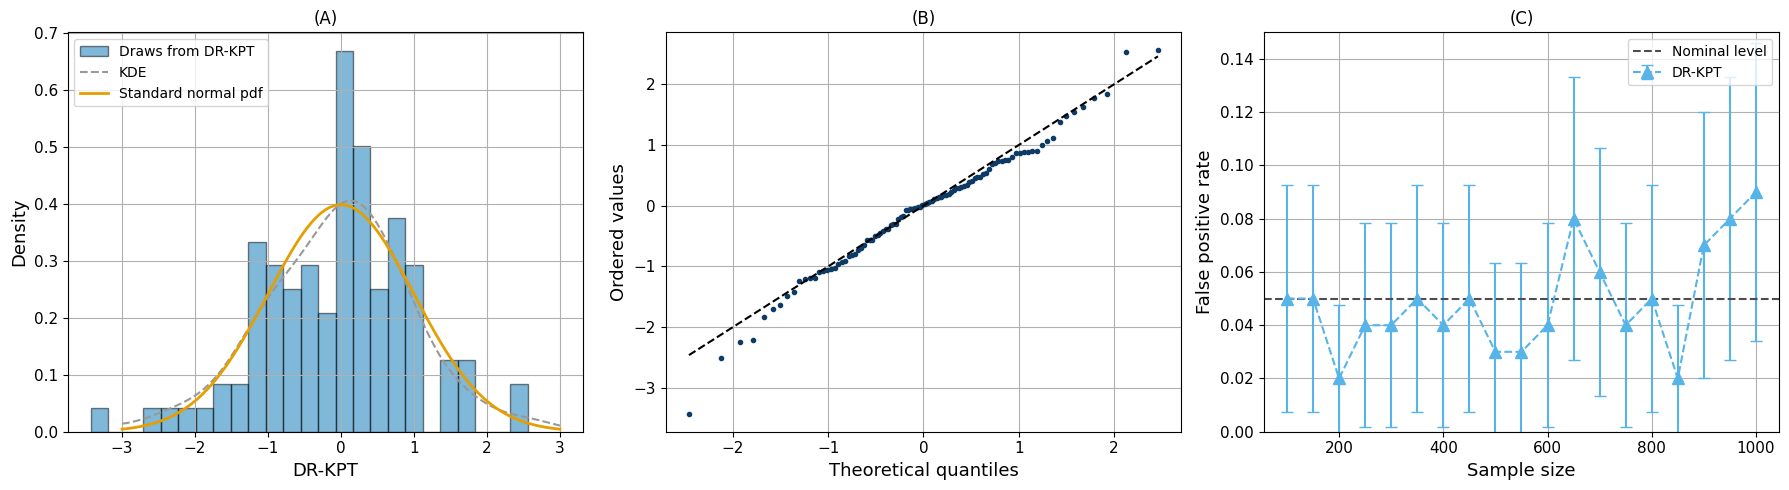

In [9]:
plot_null_diagnostics_observational(
    d_results,
    scenario="I",
    method="DR-CF",
    ns=400,
    name_folder="results/",
    ns_list=np.arange(100, 1050, 50),
    confidence_level=0.05,
    save_path="plots/null_scenarioI_errorbar.png"
)


In [ ]:
plot_null_diagnostics_observational(
    d_results,
    scenario="I",
    method="DR",
    ns=400,
    name_folder="results/",
    ns_list=np.arange(100, 1050, 50),
    confidence_level=0.05,
    save_path="plots/null_dr_nonCF_scenarioI_errorbar.png",
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_power_scenarios_observational(
    d,
    scenario_list=["II", "III", "IV"],
    ns_list=[100, 150, 200, 250, 300, 350],
    methods=["PE-linear", "KPE", "DR-CF"],
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/scenarios234_errorbar.png",
):
    # === Styling ===
    plt.rcParams["figure.figsize"] = (16, 4)
    plt.rc("legend", fontsize=12)
    plt.rc("axes", labelsize=15)
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)
    plt.rcParams["axes.grid"] = True

    fig, axs = plt.subplots(1, 3, constrained_layout=True)

    # === Mappings ===
    method_dict = {"DR": "DR", "KPE": "KPT", "DR-CF": "DR-KPT", "PE-linear": "PT-linear"}
    colors = {
        "PE-linear": "#E69F00",
        "KPE": "#0072B2",
        "DR-CF": "#009E73",
        "DR": "#56B4E9"
    }
    m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}
    scenario_titles = {"II": "(II)", "III": "(III)", "IV": "(IV)"}
    ns_array = np.array(ns_list)

    for col, scenario in enumerate(scenario_list):
        ax = axs[col]
        ax.set_title(scenario_titles[scenario])
        ax.set_ylim((-0.05, 1.05))
        ax.set_xlabel("Sample size")
        ax.set_xticks(ns_list)
        ax.grid(True, linestyle="--", alpha=0.6)
        if col == 0:
            ax.set_ylabel("True positive rate")

        for i, method in enumerate(methods):
            rejection_proportion = []
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}_scenario{scenario}_{method}.csv"
                pvals = d[fname]["p_value"]
                rej = (pvals < confidence_level).mean()
                rejection_proportion.append(rej)
            rejection_proportion = np.array(rejection_proportion)
            varhat = rejection_proportion * (1 - rejection_proportion) / len(pvals)
            ax.errorbar(
                x=ns_array,
                y=rejection_proportion,
                yerr=1.96 * np.sqrt(varhat),
                capsize=4,
                marker=m_dict[i],
                linestyle='--',
                linewidth=1.5,
                markersize=8,
                label=method_dict[method],
                color=colors.get(method, "#333333")
            )
        ax.axhline(confidence_level, color="black", linestyle=":", linewidth=1)
        ax.legend(loc="lower left")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


In [ ]:
plot_power_scenarios_observational(
    d=d_results,
    scenario_list=["II", "III", "IV"],
    ns_list=list(np.arange(100, 450, 50)),
    methods=["DR-CF", "KPE", "PE-linear"],
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/continuous_scenarios234_errorbar.png"
)